In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

In [4]:
df = pd.read_csv('Algerian_forest_fires_cleaned_dataset.csv')

In [7]:
df.head()
#here we will see that day,month,year is not in our use so we will drop them

,day,month,year,Temperature,RH,Ws,Rain,FFMC,DMC,DC,ISI,BUI,FWI,Classes,Region
0,1,6,2012,29,57,18.0,0.0,65.7,3.4,7.6,1.3,3.4,0.5,not fire,0
1,2,6,2012,29,61,13.0,1.3,64.4,4.1,7.6,1.0,3.9,0.4,not fire,0
2,3,6,2012,26,82,22.0,13.1,47.1,2.5,7.1,0.3,2.7,0.1,not fire,0
3,4,6,2012,25,89,13.0,2.5,28.6,1.3,6.9,0.0,1.7,0.0,not fire,0
4,5,6,2012,27,77,16.0,0.0,64.8,3.0,14.2,1.2,3.9,0.5,not fire,0


In [8]:
df.tail()

,day,month,year,Temperature,RH,Ws,Rain,FFMC,DMC,DC,ISI,BUI,FWI,Classes,Region
237,26,9,2012,30,65,14.0,0.0,85.4,16.0,44.5,4.5,16.9,6.5,fire,1
238,27,9,2012,28,87,15.0,4.4,41.1,6.5,8.0,0.1,6.2,0.0,not fire,1
239,28,9,2012,27,87,29.0,0.5,45.9,3.5,7.9,0.4,3.4,0.2,not fire,1
240,29,9,2012,24,54,18.0,0.1,79.7,4.3,15.2,1.7,5.1,0.7,not fire,1
241,30,9,2012,24,64,15.0,0.2,67.3,3.8,16.5,1.2,4.8,0.5,not fire,1


In [9]:
df.drop(['day','month','year'],inplace = True , axis = 1)

In [10]:
df

,Temperature,RH,Ws,Rain,FFMC,DMC,DC,ISI,BUI,FWI,Classes,Region
0,29,57,18.0,0.0,65.7,3.4,7.6,1.3,3.4,0.5,not fire,0
1,29,61,13.0,1.3,64.4,4.1,7.6,1.0,3.9,0.4,not fire,0
2,26,82,22.0,13.1,47.1,2.5,7.1,0.3,2.7,0.1,not fire,0
3,25,89,13.0,2.5,28.6,1.3,6.9,0.0,1.7,0.0,not fire,0
4,27,77,16.0,0.0,64.8,3.0,14.2,1.2,3.9,0.5,not fire,0
...,...,...,...,...,...,...,...,...,...,...,...,...
237,30,65,14.0,0.0,85.4,16.0,44.5,4.5,16.9,6.5,fire,1
238,28,87,15.0,4.4,41.1,6.5,8.0,0.1,6.2,0.0,not fire,1
239,27,87,29.0,0.5,45.9,3.5,7.9,0.4,3.4,0.2,not fire,1
240,24,54,18.0,0.1,79.7,4.3,15.2,1.7,5.1,0.7,not fire,1


In [11]:
df.columns

Index(['Temperature', 'RH', 'Ws', 'Rain', 'FFMC', 'DMC', 'DC', 'ISI', 'BUI',
       'FWI', 'Classes', 'Region'],
      dtype='object')

In [13]:
df['Classes'].value_counts()
#here we will see that fire and not fire have different values because of spacing and all

Classes
fire             131
not fire         100
fire               4
fire               2
not fire           2
not fire           1
not fire           1
not fire           1
Name: count, dtype: int64

In [14]:
#Encoding
df['Classes'] = np.where(df['Classes'].str.contains('not fire'),0,1)

In [15]:
df.head()

,Temperature,RH,Ws,Rain,FFMC,DMC,DC,ISI,BUI,FWI,Classes,Region
0,29,57,18.0,0.0,65.7,3.4,7.6,1.3,3.4,0.5,0,0
1,29,61,13.0,1.3,64.4,4.1,7.6,1.0,3.9,0.4,0,0
2,26,82,22.0,13.1,47.1,2.5,7.1,0.3,2.7,0.1,0,0
3,25,89,13.0,2.5,28.6,1.3,6.9,0.0,1.7,0.0,0,0
4,27,77,16.0,0.0,64.8,3.0,14.2,1.2,3.9,0.5,0,0


In [16]:
df.tail()

,Temperature,RH,Ws,Rain,FFMC,DMC,DC,ISI,BUI,FWI,Classes,Region
237,30,65,14.0,0.0,85.4,16.0,44.5,4.5,16.9,6.5,1,1
238,28,87,15.0,4.4,41.1,6.5,8.0,0.1,6.2,0.0,0,1
239,27,87,29.0,0.5,45.9,3.5,7.9,0.4,3.4,0.2,0,1
240,24,54,18.0,0.1,79.7,4.3,15.2,1.7,5.1,0.7,0,1
241,24,64,15.0,0.2,67.3,3.8,16.5,1.2,4.8,0.5,0,1


In [17]:
df['Classes'].value_counts()

Classes
1    137
0    105
Name: count, dtype: int64

In [18]:
#Independent and dependent features
X = df.drop('FWI',axis = 1)
y = df['FWI']


In [19]:
X.head()

,Temperature,RH,Ws,Rain,FFMC,DMC,DC,ISI,BUI,Classes,Region
0,29,57,18.0,0.0,65.7,3.4,7.6,1.3,3.4,0,0
1,29,61,13.0,1.3,64.4,4.1,7.6,1.0,3.9,0,0
2,26,82,22.0,13.1,47.1,2.5,7.1,0.3,2.7,0,0
3,25,89,13.0,2.5,28.6,1.3,6.9,0.0,1.7,0,0
4,27,77,16.0,0.0,64.8,3.0,14.2,1.2,3.9,0,0


In [20]:
y

0      0.5
1      0.4
2      0.1
3      0.0
4      0.5
      ... 
237    6.5
238    0.0
239    0.2
240    0.7
241    0.5
Name: FWI, Length: 242, dtype: float64

In [55]:
#Train Test Split
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size = 0.25,random_state = 42)

In [56]:
X_train.shape,y_train.shape


((181, 11), (181,))

In [57]:
X_test.shape,y_test.shape

((61, 11), (61,))

In [58]:
type(X)

pandas.core.frame.DataFrame

In [59]:
type(y)

pandas.core.series.Series

In [60]:
#Feature selection based on independent and dependent features
X_train.corr()


,Temperature,RH,Ws,Rain,FFMC,DMC,DC,ISI,BUI,Classes,Region
Temperature,1.000000,-0.650346,-0.302105,-0.329711,0.703237,0.494261,0.377424,0.617606,0.466352,0.525551,0.249598
RH,-0.650346,1.000000,0.266525,0.234932,-0.634330,-0.413931,-0.246125,-0.693939,-0.364136,-0.435094,-0.364007
Ws,-0.302105,0.266525,1.000000,0.219681,-0.171843,0.000277,0.105115,0.005360,0.038701,-0.059470,-0.235477
Rain,-0.329711,0.234932,0.219681,1.000000,-0.546501,-0.286855,-0.300276,-0.346706,-0.297934,-0.386323,-0.065132
FFMC,0.703237,-0.634330,-0.171843,-0.546501,1.000000,0.621240,0.537884,0.751558,0.610780,0.780805,0.222702
DMC,0.494261,-0.413931,0.000277,-0.286855,0.621240,1.000000,0.876734,0.693404,0.983698,0.613507,0.196778
DC,0.377424,-0.246125,0.105115,-0.300276,0.537884,0.876734,1.000000,0.548992,0.946992,0.546427,-0.081403
ISI,0.617606,-0.693939,0.005360,-0.346706,0.751558,0.693404,0.548992,1.000000,0.659589,0.749722,0.266275
BUI,0.466352,-0.364136,0.038701,-0.297934,0.610780,0.983698,0.946992,0.659589,1.000000,0.609708,0.096607
Classes,0.525551,-0.435094,-0.059470,-0.386323,0.780805,0.613507,0.546427,0.749722,0.609708,1.000000,0.161852


In [61]:
print(type(X_train))

<class 'pandas.core.frame.DataFrame'>


In [63]:
X_train.corr

<bound method DataFrame.corr of      Temperature  RH    Ws  Rain  FFMC   DMC    DC  ISI   BUI  Classes  Region
97            29  74  19.0   0.1  75.8   3.6  32.2  2.1   5.6        0       0
141           32  55  14.0   0.0  86.2   8.3  18.4  5.0   8.2        1       1
230           29  41   8.0   0.1  83.9  24.9  86.0  2.7  28.9        1       1
68            32  60  18.0   0.3  77.1  11.3  47.0  2.2  14.1        0       0
119           32  47  14.0   0.7  77.5   7.1   8.8  1.8   6.8        0       0
..           ...  ..   ...   ...   ...   ...   ...  ...   ...      ...     ...
106           24  82  15.0   0.4  44.9   0.9   7.3  0.2   1.4        0       0
14            28  80  17.0   3.1  49.4   3.0   7.4  0.4   3.0        0       0
92            25  76  17.0   7.2  46.0   1.3   7.5  0.2   1.8        0       0
179           36  56  16.0   0.0  88.9  23.8  57.1  8.2  23.8        1       1
102           30  77  21.0   1.8  58.5   1.9   8.4  1.1   2.4        0       0

[181 rows x 11 colu

<Axes: >

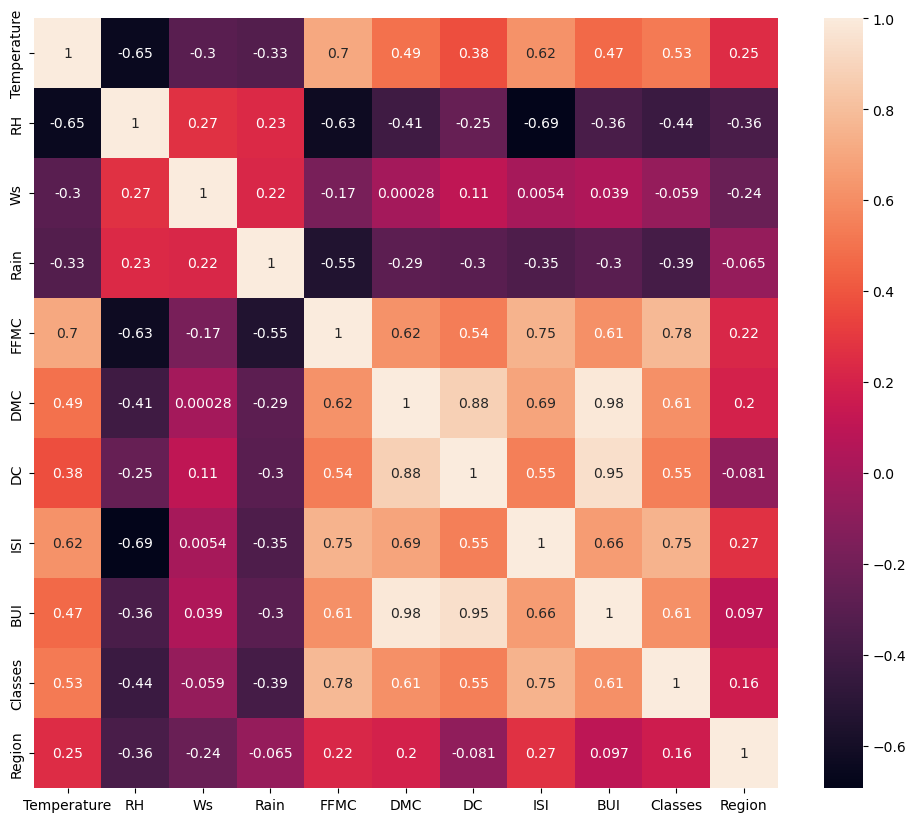

In [65]:
#Check for multicollinearity
plt.figure(figsize = (12,10))
corr = X_train.corr()
sns.heatmap(corr,annot = True)
#here we will see with the diagram how much variables are correlated with each other



In [67]:
#now we will take those features those are not that much correlated
def correlation(dataset,threshold):
    col_corr = set()
    corr_matrix = dataset.corr()
    for i in range (len(corr_matrix.columns)):
        for j in range(i):
            if abs(corr_matrix.iloc[i,j]>threshold):
                colname = corr_matrix.columns[i]
                col_corr.add(colname)
    return col_corr

In [71]:
corr_features = correlation(X_train,0.85)
corr_features
#gives those features which are highly correlated whose value greater than the threshold value i.e >85%

{'BUI', 'DC'}

In [78]:
type(X_train) , type(X_test)

(pandas.core.frame.DataFrame, pandas.core.frame.DataFrame)

In [80]:
print(type(corr_features))

<class 'set'>


In [81]:
print(X_train.columns)

Index(['Temperature', 'RH', 'Ws', 'Rain', 'FFMC', 'DMC', 'ISI', 'Classes',
       'Region'],
      dtype='object')


In [82]:
X_train.drop(corr_features,axis = 1,errors = 'ignore',inplace = True)
X_test.drop(corr_features,axis = 1,errors = 'ignore',inplace = True)
X_train.shape , X_test.shape

((181, 9), (61, 9))

In [83]:
X_train


,Temperature,RH,Ws,Rain,FFMC,DMC,ISI,Classes,Region
97,29,74,19.0,0.1,75.8,3.6,2.1,0,0
141,32,55,14.0,0.0,86.2,8.3,5.0,1,1
230,29,41,8.0,0.1,83.9,24.9,2.7,1,1
68,32,60,18.0,0.3,77.1,11.3,2.2,0,0
119,32,47,14.0,0.7,77.5,7.1,1.8,0,0
...,...,...,...,...,...,...,...,...,...
106,24,82,15.0,0.4,44.9,0.9,0.2,0,0
14,28,80,17.0,3.1,49.4,3.0,0.4,0,0
92,25,76,17.0,7.2,46.0,1.3,0.2,0,0
179,36,56,16.0,0.0,88.9,23.8,8.2,1,1


In [84]:
#feature scaling and standarization
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler .transform(X_test)

In [85]:
X_train_scaled

array([[-0.82836812,  0.75305576,  1.27406033, ..., -0.60658617,
        -1.07459849, -0.98356052],
       [-0.02800533, -0.52331623, -0.52192814, ...,  0.08124507,
         0.93058013,  1.01671425],
       [-0.82836812, -1.46380085, -2.67711431, ..., -0.46427625,
         0.93058013,  1.01671425],
       ...,
       [-1.89551851,  0.88741071,  0.55566494, ..., -1.05723422,
        -1.07459849, -0.98356052],
       [ 1.03914506, -0.45613875,  0.19646725, ...,  0.84023126,
         0.93058013,  1.01671425],
       [-0.56158052,  0.95458818,  1.99245572, ..., -0.84376935,
        -1.07459849, -0.98356052]], shape=(181, 9))

Text(0.5, 1.0, 'X_train after scaling')

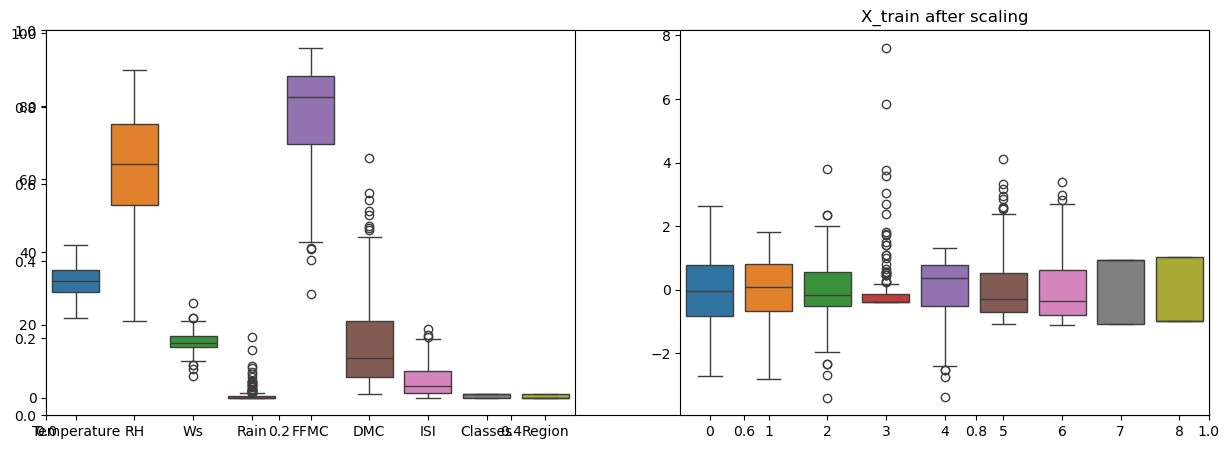

In [99]:
#Box plot to understand effect of Standard Scaler
plt.subplots(figsize = (15,5))
plt.subplot(1,2,1)
sns.boxplot(data = X_train)
plt.subplot(1,2,2)
sns.boxplot(data = X_train_scaled)
plt.title('X_train after scaling')

In [101]:
#Linear Regression Model
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import r2_score
linreg = LinearRegression()
linreg.fit(X_train_scaled,y_train)
y_pred = linreg.predict(X_test_scaled)
mae = mean_absolute_error(y_test,y_pred)
score = r2_score(y_test,y_pred)
print('Mean absolute error',mae)
print('R_2 score',score)
#here we will see the accuracy of 98% which is very good that means we have trained a very good model



Mean absolute error 0.5838063599546969
R_2 score 0.983523052949508


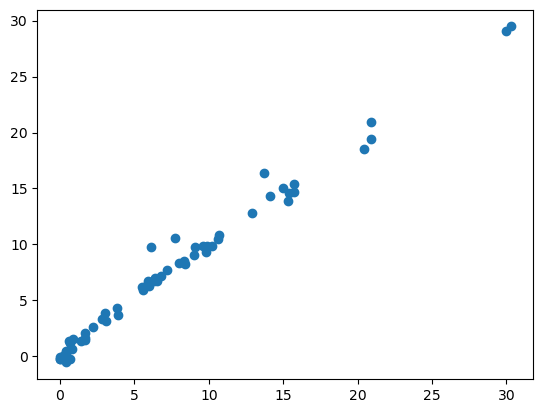

In [103]:
plt.scatter(y_test,y_pred)
#here we will see the very good linear relation between the features

In [116]:
#Lasso Regression
from sklearn.linear_model import Lasso
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import r2_score
lasso = Lasso()
lasso.fit(X_train_scaled,y_train)
y_pred = lasso.predict(X_test_scaled)
mae = mean_absolute_error(y_test,y_pred)
score = r2_score(y_test,y_pred)
print('Mean absolute error',mae)
print('R_2 score',score)

Mean absolute error 1.1459979969391694
R_2 score 0.9497712193501187


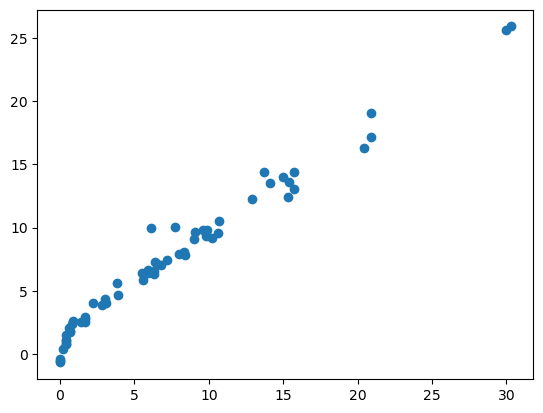

In [118]:
plt.scatter(y_test,y_pred)
#here we will see accuracy of 94%

In [119]:
#Cross Validation of Lasso Regression
from sklearn.linear_model import LassoCV
lassocv = LassoCV(cv = 5)
lassocv.fit(X_train_scaled,y_train)
lassocv.predict(X_test_scaled)

array([ 8.20369611,  7.66752483,  7.01694316,  6.44164095,  6.87995085,
       10.45071211, 10.74749039,  2.94887295,  1.94009643,  3.41796668,
        0.69404823, 10.01585512,  9.38743616, 28.65997022, 18.26984651,
        1.01251376,  4.74458394, -0.7867153 ,  7.31308086,  6.13501941,
        1.94095525,  0.13158713,  6.47046101,  0.12311714, 20.8291544 ,
       14.29840087,  5.91602708,  9.79061958, -0.91287688, 14.94452271,
        6.80932333, -0.34981173, 10.35343136, 14.48678119,  1.68860744,
        3.18803948,  2.11859296,  6.07971374, -0.11535929, -0.44707149,
        6.52025058,  2.00836064,  8.46437828, -0.95269592, 15.34241258,
        8.37687701,  9.90033717,  1.39214078,  0.23289036,  1.21181138,
       29.05538651,  3.74389811, 12.90120028, 19.26121013, 13.68083892,
       16.18966676,  9.89411858,  9.14963522,  3.94107144, 14.42862416,
        9.96684186])

In [120]:
lassocv.alpha_

np.float64(0.06481103951672902)

In [121]:
lassocv.alphas_

array([6.94947533, 6.48110395, 6.04429924, 5.6369337 , 5.25702323,
       4.90271746, 4.57229071, 4.26413362, 3.97674529, 3.70872596,
       3.45877025, 3.22566071, 3.00826197, 2.80551518, 2.61643285,
       2.44009403, 2.27563986, 2.12226935, 1.9792355 , 1.84584165,
       1.7214381 , 1.60541894, 1.49721907, 1.39631152, 1.3022048 ,
       1.21444055, 1.13259132, 1.05625846, 0.98507017, 0.91867974,
       0.8567638 , 0.79902079, 0.74516946, 0.69494753, 0.6481104 ,
       0.60442992, 0.56369337, 0.52570232, 0.49027175, 0.45722907,
       0.42641336, 0.39767453, 0.3708726 , 0.34587702, 0.32256607,
       0.3008262 , 0.28055152, 0.26164329, 0.2440094 , 0.22756399,
       0.21222694, 0.19792355, 0.18458417, 0.17214381, 0.16054189,
       0.14972191, 0.13963115, 0.13022048, 0.12144406, 0.11325913,
       0.10562585, 0.09850702, 0.09186797, 0.08567638, 0.07990208,
       0.07451695, 0.06949475, 0.06481104, 0.06044299, 0.05636934,
       0.05257023, 0.04902717, 0.04572291, 0.04264134, 0.03976

In [122]:
lassocv.mse_path_

array([[54.83966454, 59.07855795, 38.72729712, 78.24916791, 53.00661707],
       [48.33127443, 52.98238939, 33.40705056, 76.17370919, 47.37592787],
       [42.489492  , 46.9476325 , 28.61641869, 69.11179183, 42.46600092],
       [37.38816074, 41.6222327 , 24.54198449, 62.88571919, 38.18380814],
       [32.93231013, 36.95463498, 21.08421335, 57.39228141, 33.53847098],
       [29.03908563, 32.86149181, 18.15701813, 52.54133041, 29.14966015],
       [25.63631212, 29.27011099, 15.68586523, 48.25410422, 25.34331445],
       [22.66140204, 26.11749884, 13.60632992, 43.16468118, 22.0425561 ],
       [20.05957707, 23.34834079, 11.86266757, 37.9874641 , 19.18168383],
       [17.78321296, 20.91452315, 10.40680285, 33.46741145, 16.70233718],
       [15.79082322, 18.77407566,  9.19714128, 29.52048402, 14.5542223 ],
       [14.0461701 , 16.89025254,  8.19780164, 26.07233474, 12.69363691],
       [12.51796119, 15.23137028,  7.37783328, 23.06047803, 11.08260866],
       [11.17864417, 13.76938633,  6.7

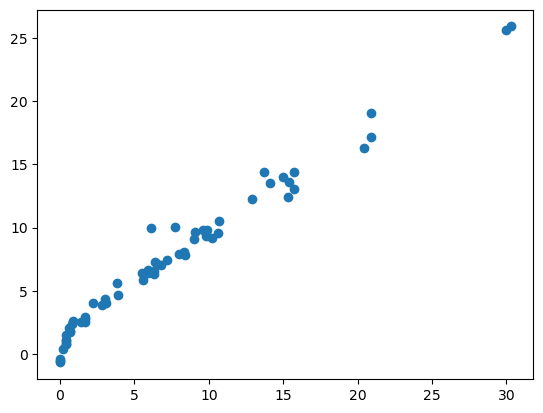

In [123]:
#Check Accuracy
y_pred - lassocv.predict(X_test_scaled)
plt.scatter(y_test,y_pred)

In [124]:
mae = mean_absolute_error(y_test,y_pred)
score = r2_score(y_test,y_pred)
print(mae)
print(score)
#here we will see the same accuracy

1.1459979969391694
0.9497712193501187


In [129]:
#Ridge Regression
from sklearn.linear_model import Ridge
from sklearn.metrics import r2_score
ridge = Ridge()
ridge.fit(X_train_scaled,y_train)
y_pred = ridge.predict(X_test_scaled)
mae = mean_absolute_error(y_test,y_pred)
score = r2_score(y_test,y_pred)
print('Mean absolute error',mae)
print('R_2 score',score)

#here we will see the accuracy of 98%

Mean absolute error 0.612551563810103
R_2 score 0.9826983552292979


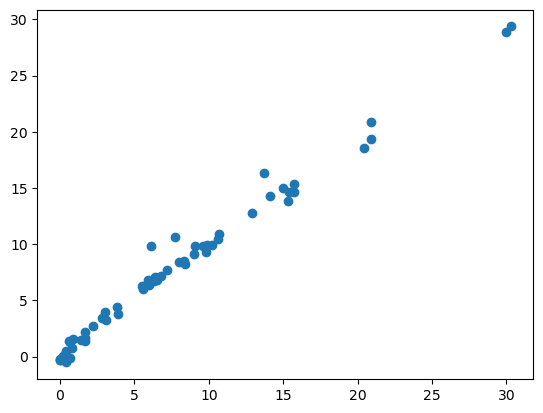

In [131]:
plt.scatter(y_test,y_pred)
#here we will see the accuracy of 98%

In [133]:
#Cross validation of Ridge Regression
from sklearn.linear_model import RidgeCV
ridgecv = RidgeCV()
ridgecv = LassoCV(cv = 5)
ridgecv.fit(X_train_scaled,y_train)
ridgecv.predict(X_test_scaled)

array([ 8.20369611,  7.66752483,  7.01694316,  6.44164095,  6.87995085,
       10.45071211, 10.74749039,  2.94887295,  1.94009643,  3.41796668,
        0.69404823, 10.01585512,  9.38743616, 28.65997022, 18.26984651,
        1.01251376,  4.74458394, -0.7867153 ,  7.31308086,  6.13501941,
        1.94095525,  0.13158713,  6.47046101,  0.12311714, 20.8291544 ,
       14.29840087,  5.91602708,  9.79061958, -0.91287688, 14.94452271,
        6.80932333, -0.34981173, 10.35343136, 14.48678119,  1.68860744,
        3.18803948,  2.11859296,  6.07971374, -0.11535929, -0.44707149,
        6.52025058,  2.00836064,  8.46437828, -0.95269592, 15.34241258,
        8.37687701,  9.90033717,  1.39214078,  0.23289036,  1.21181138,
       29.05538651,  3.74389811, 12.90120028, 19.26121013, 13.68083892,
       16.18966676,  9.89411858,  9.14963522,  3.94107144, 14.42862416,
        9.96684186])

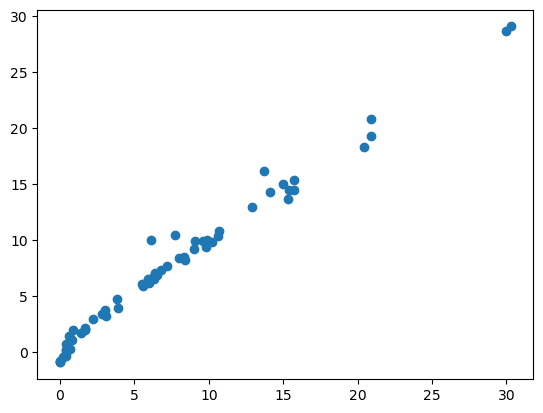

In [134]:
#Check Accuracy
y_pred = ridgecv.predict(X_test_scaled)
plt.scatter(y_test,y_pred)

In [136]:
mae = mean_absolute_error(y_test,y_pred)
score = r2_score(y_test,y_pred)
print(mae)
print(score)
#here we will see the accuracy of 98%

0.6701641696301904
0.9808648686248684


In [138]:
ridgecv.get_params()
#gives all the parameters

{'alphas': 'warn',
 'copy_X': True,
 'cv': 5,
 'eps': 0.001,
 'fit_intercept': True,
 'max_iter': 1000,
 'n_alphas': 'deprecated',
 'n_jobs': None,
 'positive': False,
 'precompute': 'auto',
 'random_state': None,
 'selection': 'cyclic',
 'tol': 0.0001,
 'verbose': False}

In [142]:
#ElasticNet Regression
from sklearn.linear_model import ElasticNet
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import r2_score
elasticnet = ElasticNet()
elasticnet.fit(X_train_scaled , y_train)
y_pred = elasticnet.predict(X_test_scaled)
mae = mean_absolute_error(y_test,y_pred)
score = r2_score(y_test,y_pred)
print(mae)
print(score)

1.8915134363047037
0.8731354681001338


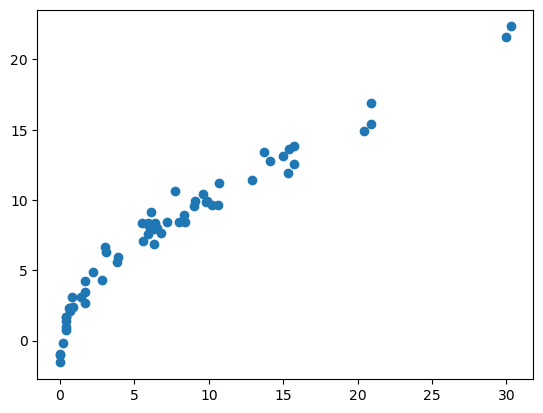

In [144]:
plt.scatter(y_test,y_pred)
#here we will see the accuracy of 87%

In [146]:
#Cross Validation of ElasticNet Regression
from sklearn.linear_model import ElasticNetCV
elasticnet = ElasticNetCV()
elasticnet = ElasticNetCV(cv = 5)
elasticnet.fit(X_train_scaled,y_train)
elasticnet.predict(X_test_scaled)

array([ 8.29799676,  7.77376925,  7.21936017,  6.96173455,  6.97774377,
       10.67267869, 10.92630332,  3.0385085 ,  1.62031173,  3.57183213,
        0.72699624,  9.89940779,  9.4439304 , 28.29417474, 18.25473207,
        1.00265396,  4.57026161, -0.7781811 ,  7.26902752,  6.53677102,
        1.62036074,  0.06766691,  6.65165944,  0.2927794 , 20.49329709,
       14.25537639,  6.10714345,  9.88121184, -0.75394329, 14.90282511,
        6.83586017, -0.35250582, 10.46474701, 14.55718819,  1.66145696,
        3.458631  ,  2.35379964,  6.4855845 , -0.08889351, -0.1087909 ,
        6.85557629,  1.82800512,  8.57188716, -0.86683725, 15.24230308,
        8.44967528,  9.93153272,  1.3528024 ,  0.28617694,  1.31614097,
       28.91730771,  4.34053853, 12.85355555, 19.07282571, 13.71482904,
       16.26211244,  9.9331303 ,  9.23942498,  4.00599966, 14.56001625,
       10.00645026])

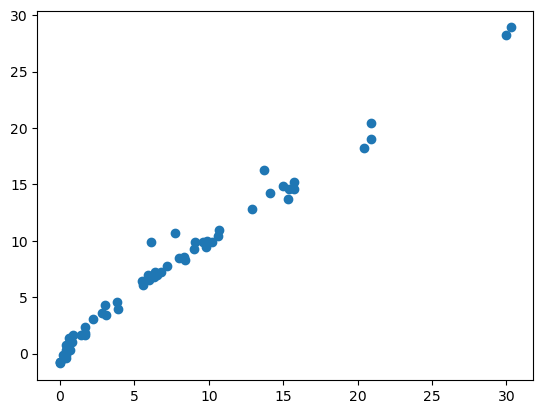

In [147]:
#Check Accuracy
y_pred = elasticnet.predict(X_test_scaled)
plt.scatter(y_test,y_pred)

In [149]:
mae = mean_absolute_error(y_test,y_pred)
score = r2_score(y_test,y_pred)
print(mae)
print(score)
#here it will give the accuracy of 97%

0.7295307419548663
0.9789324233433637


#MODEL PICKLING IN ML PROJECT

In [152]:
scaler
ridge
import pickle
pickle.dump(scaler,open('scaler.pkl','wb'))
pickle.dump(ridge,open('ridge.pkl','wb'))
#here this pickle file saved in hardisk when deploy this model on AWS cloud then we upload this pickle file